depth=4, n=200, lr=0.05 --> val_acc=0.6793
depth=4, n=200, lr=0.1 --> val_acc=0.6922
depth=6, n=200, lr=0.05 --> val_acc=0.6977
depth=6, n=200, lr=0.1 --> val_acc=0.7091
depth=8, n=200, lr=0.05 --> val_acc=0.7077
depth=8, n=200, lr=0.1 --> val_acc=0.7145

Best Params: (8, 200, 0.1, 0.7145026575550494)


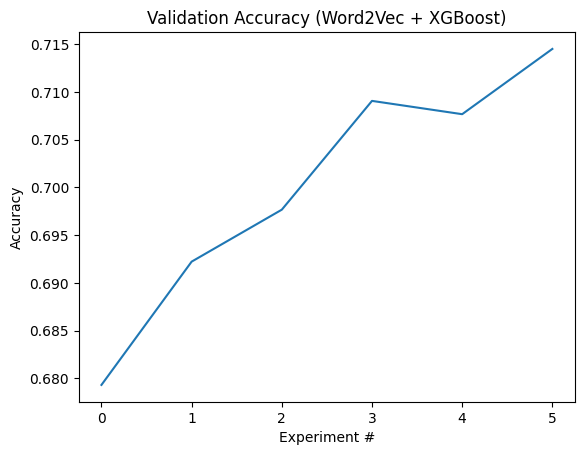

FINAL TEST RESULTS (Word2Vec + XGBoost)
Accuracy: 0.7265595343540427
Precision: 0.7210479852405832
Recall: 0.7265595343540427
F1 Score: 0.7193748381894384

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.73      0.60      0.66       576
             Bipolar       0.69      0.53      0.60       417
          Depression       0.67      0.72      0.69      2311
              Normal       0.83      0.94      0.89      2452
Personality disorder       0.82      0.43      0.57       161
              Stress       0.58      0.43      0.49       388
            Suicidal       0.66      0.60      0.63      1598

            accuracy                           0.73      7903
           macro avg       0.71      0.61      0.65      7903
        weighted avg       0.72      0.73      0.72      7903



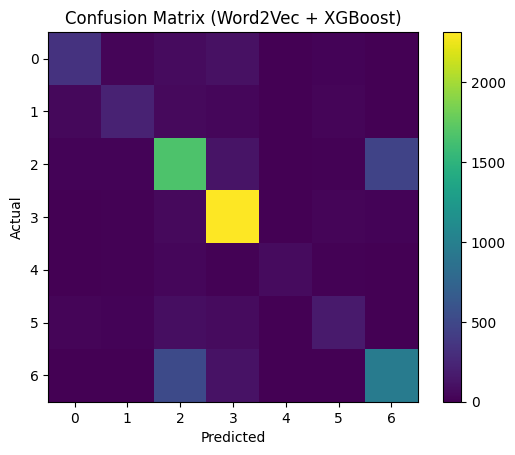

In [8]:

!pip install gensim tensorflow pandas matplotlib scikit-learn xgboost

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from gensim.models import Word2Vec

df = pd.read_csv('mental_health.csv')
df = df.dropna(subset=['statement', 'status']).copy()


df['statement'] = df['statement'].str.lower()

x = df['statement'].astype(str)
y = df['status']


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

tokenized_train = [text.split() for text in x_train]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)


def sentence_vector(sentence, model):
    words = sentence.split()
    vectors = [model.wv[word] for word in words if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


X_train_w2v = np.array([sentence_vector(text, w2v_model) for text in x_train])
X_val_w2v   = np.array([sentence_vector(text, w2v_model) for text in x_val])
X_test_w2v  = np.array([sentence_vector(text, w2v_model) for text in x_test])


results = []

for depth in [4, 6, 8]:
        for lr in [0.05, 0.1]:

            model = XGBClassifier(
                max_depth=depth,
                n_estimators=200,
                learning_rate=lr,
                objective='multi:softmax',
                num_class=num_classes,
                eval_metric='mlogloss',
                random_state=42
            )

            model.fit(X_train_w2v, y_train)
            val_pred = model.predict(X_val_w2v)
            acc = accuracy_score(y_val, val_pred)

            results.append((depth, n, lr, acc))
            print(f"depth={depth}, n={n}, lr={lr} --> val_acc={acc:.4f}")

best = max(results, key=lambda x: x[3])
best_depth, best_n, best_lr, _ = best

print("\nBest Params:", best)

plt.figure()
plt.plot([r[3] for r in results])
plt.title("Validation Accuracy (Word2Vec + XGBoost)")
plt.xlabel("Experiment #")
plt.ylabel("Accuracy")
plt.show()


X_train_final = np.vstack((X_train_w2v, X_val_w2v))
y_train_final = np.concatenate((y_train, y_val))

final_model = XGBClassifier(
    max_depth=best_depth,
    n_estimators=best_n,
    learning_rate=best_lr,
    objective='multi:softmax',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42
)

final_model.fit(X_train_final, y_train_final)


y_test_pred = final_model.predict(X_test_w2v)

print("FINAL TEST RESULTS (Word2Vec + XGBoost)")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=label_encoder.classes_
))


plt.figure()
cm = confusion_matrix(y_test, y_test_pred)
plt.imshow(cm)
plt.title("Confusion Matrix (Word2Vec + XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()